# Практическое задание 4.

Ноутбук выполняет задания из исходного файла:

1. реализует EM для GLAD-модели;
2. сравнивает GLAD с голосованием большинством;
3. анализирует коэффициенты экспертов `alpha`;
4. добавляет известные контрольные ответы;
5. скачивает корпус CzEnAli, если его нет в текущей папке;
6. реализует парсер, токенизацию, метрики качества, `WordAligner` и `WordPositionAligner`;
7. строит примеры переводов и визуализации выравниваний.

Запускайте ноутбук из папки, где лежат `L.npy` и `y.npy`. Если корпус для word alignment отсутствует, он будет скачан автоматически.


## 0. Импорты и настройки


In [1]:
import os
import glob
import tarfile
import urllib.request
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt

def expit(x):
    """Stable sigmoid implemented with NumPy."""
    x = np.asarray(x, dtype=float)
    out = np.empty_like(x, dtype=float)
    positive = x >= 0
    out[positive] = 1 / (1 + np.exp(-x[positive]))
    exp_x = np.exp(x[~positive])
    out[~positive] = exp_x / (1 + exp_x)
    return out


def logsumexp(a, axis=None, keepdims=False):
    """Stable log(sum(exp(a))) implemented with NumPy."""
    a = np.asarray(a, dtype=float)
    a_max = np.max(a, axis=axis, keepdims=True)
    out = np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True)) + a_max
    if not keepdims:
        out = np.squeeze(out, axis=axis)
    return out


seed = 0xDEADF00D
rng = np.random.default_rng(seed)
np.random.seed(seed)


## 1. GLAD: загрузка данных


In [2]:
L = np.load('L.npy')
y = np.load('y.npy')

n, m = L.shape
print('L.shape =', L.shape)
print('y.shape =', y.shape)
print('Ответы экспертов:', dict(zip(*np.unique(L, return_counts=True))))
print('Истинные классы:', dict(zip(*np.unique(y, return_counts=True))))


L.shape = (2000, 20)
y.shape = (2000,)
Ответы экспертов: {np.int64(0): np.int64(19824), np.int64(1): np.int64(20176)}
Истинные классы: {np.int64(0): np.int64(1009), np.int64(1): np.int64(991)}


## 2. GLAD: функции EM-алгоритма


In [3]:
def softplus(x):
    """Stable log(1 + exp(x))."""
    return np.logaddexp(0.0, x)

def posterior(alpha, beta, L, known_labels=None):
    """
    Апостериорное распределение q_i(z)=p(z_i | L_i, alpha, beta).
    Возвращает q shape (2, n_problems), где q[z, i] = p(z_i=z | ...).
    """
    logits = np.outer(beta, alpha)
    logp = []
    for z in (0, 1):
        signs = np.where(L == z, 1.0, -1.0)
        log_prob_labels = -softplus(-signs * logits)
        logp_z = np.log(0.5) + log_prob_labels.sum(axis=1)
        logp.append(logp_z)

    logp = np.vstack(logp)
    logp -= logsumexp(logp, axis=0, keepdims=True)
    q = np.exp(logp)

    if known_labels is not None:
        known_labels = np.asarray(known_labels, dtype=float)
        mask = ~np.isnan(known_labels)
        idx = np.where(mask)[0]
        labs = known_labels[mask].astype(int)
        q[:, idx] = 0.0
        q[labs, idx] = 1.0

    return q


def log_likelihood(alpha, beta, L, z):
    """log p(L | z, alpha, beta) для заданного вектора истинных меток z."""
    logits = np.outer(beta, alpha)
    z = np.asarray(z).astype(int)
    signs = np.where(L == z[:, None], 1.0, -1.0)
    return (-softplus(-signs * logits)).sum(axis=1)


def alpha_grad_lb(alpha, beta, L, q):
    """Градиент нижней оценки по alpha."""
    logits = np.outer(beta, alpha)
    grad = np.zeros_like(alpha, dtype=float)
    for z in (0, 1):
        signs = np.where(L == z, 1.0, -1.0)
        grad += (q[z, :, None] * signs * beta[:, None] * expit(-signs * logits)).sum(axis=0)
    return grad


def logbeta_grad_lb(alpha, beta, L, q):
    """Градиент нижней оценки по log(beta)."""
    logits = np.outer(beta, alpha)
    grad_beta = np.zeros_like(beta, dtype=float)
    for z in (0, 1):
        signs = np.where(L == z, 1.0, -1.0)
        grad_beta += (q[z, :, None] * signs * alpha[None, :] * expit(-signs * logits)).sum(axis=1)
    return grad_beta * beta


def lower_bound(alpha, beta, L, q):
    """ELBO: E_q log p(L,z|alpha,beta) - E_q log q(z)."""
    logits = np.outer(beta, alpha)
    value = 0.0
    for z in (0, 1):
        signs = np.where(L == z, 1.0, -1.0)
        log_prob_labels = -softplus(-signs * logits)
        log_joint = np.log(0.5) + log_prob_labels.sum(axis=1)
        value += (q[z] * log_joint).sum()
    entropy_term = -(q * np.log(q + 1e-300)).sum()
    return float(value + entropy_term)


def em(L, n_steps=500, lr=1e-2, known_labels=None, random_state=seed, verbose=True):
    """
    EM для GLAD.
    M-step делается градиентным подъёмом по alpha и log(beta).
    Для устойчивости градиенты нормируются по RMS и log(beta) ограничивается.
    """
    local_rng = np.random.default_rng(random_state)
    n_problems, n_experts = L.shape

    alpha = local_rng.normal(0.0, 0.1, size=n_experts)
    logbeta = np.zeros(n_problems)
    history = []

    for step in range(n_steps):
        beta = np.exp(logbeta)
        q = posterior(alpha, beta, L, known_labels=known_labels)

        grad_alpha = alpha_grad_lb(alpha, beta, L, q)
        grad_logbeta = logbeta_grad_lb(alpha, beta, L, q)

        grad_alpha /= np.sqrt(np.mean(grad_alpha ** 2)) + 1e-8
        grad_logbeta /= np.sqrt(np.mean(grad_logbeta ** 2)) + 1e-8

        alpha += lr * grad_alpha
        logbeta += lr * grad_logbeta
        logbeta = np.clip(logbeta, -5, 5)

        if step % 25 == 0 or step == n_steps - 1:
            beta = np.exp(logbeta)
            q = posterior(alpha, beta, L, known_labels=known_labels)
            history.append(lower_bound(alpha, beta, L, q))

    if verbose:
        print(f'Последнее значение ELBO: {history[-1]:.3f}')

    return alpha, np.exp(logbeta), q, history


## 3. GLAD: обучение и сравнение с majority voting


In [4]:
def best_binary_accuracy(pred, true):
    """Accuracy с учётом возможной перестановки названий классов 0/1."""
    acc = np.mean(pred == true)
    flipped_acc = np.mean((1 - pred) == true)
    return max(acc, flipped_acc), flipped_acc > acc

alpha, beta, q, glad_history = em(L, n_steps=500, lr=1e-2, random_state=seed)

em_pred = (q[1] > q[0]).astype(int)
em_acc, need_flip = best_binary_accuracy(em_pred, y)
if need_flip:
    em_pred = 1 - em_pred
    alpha = -alpha

majority_pred = (L.mean(axis=1) >= 0.5).astype(int)
majority_acc, majority_flip = best_binary_accuracy(majority_pred, y)
if majority_flip:
    majority_pred = 1 - majority_pred

print(f'Accuracy majority voting: {majority_acc:.4f}')
print(f'Accuracy GLAD EM:         {em_acc:.4f}')
print(f'Улучшение:                {em_acc - majority_acc:+.4f}')


Последнее значение ELBO: -15710.652
Accuracy majority voting: 0.8920
Accuracy GLAD EM:         0.9535
Улучшение:                +0.0615


## 4. GLAD: график ELBO


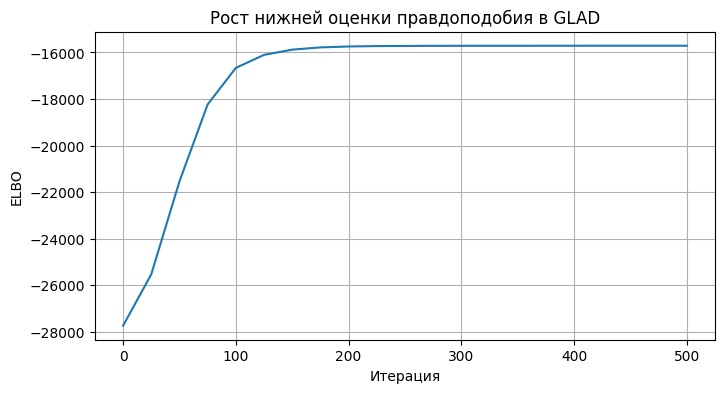

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(glad_history)) * 25, glad_history)
plt.xlabel('Итерация')
plt.ylabel('ELBO')
plt.title('Рост нижней оценки правдоподобия в GLAD')
plt.grid(True)
plt.show()


## 5. GLAD: интерпретация коэффициентов alpha


In [6]:
expert_accuracy = np.array([(L[:, j] == y).mean() for j in range(m)])
expert_accuracy_against_em = np.array([(L[:, j] == em_pred).mean() for j in range(m)])

order = np.argsort(alpha)
print('Эксперты с минимальными alpha:')
for j in order[:5]:
    print(f'  эксперт {j:2d}: alpha={alpha[j]: .3f}, accuracy true={expert_accuracy[j]:.3f}, accuracy EM={expert_accuracy_against_em[j]:.3f}')

print('\nЭксперты с максимальными alpha:')
for j in order[-5:][::-1]:
    print(f'  эксперт {j:2d}: alpha={alpha[j]: .3f}, accuracy true={expert_accuracy[j]:.3f}, accuracy EM={expert_accuracy_against_em[j]:.3f}')

bad_experts = np.where(alpha < 0)[0]
print('\nЭксперты с отрицательным alpha:', bad_experts.tolist())


Эксперты с минимальными alpha:
  эксперт 10: alpha=-2.101, accuracy true=0.083, accuracy EM=0.072
  эксперт 11: alpha=-2.005, accuracy true=0.082, accuracy EM=0.072
  эксперт  8: alpha=-1.972, accuracy true=0.090, accuracy EM=0.081
  эксперт 18: alpha=-1.867, accuracy true=0.088, accuracy EM=0.085
  эксперт  3: alpha= 0.121, accuracy true=0.674, accuracy EM=0.675

Эксперты с максимальными alpha:
  эксперт  2: alpha= 2.080, accuracy true=0.919, accuracy EM=0.927
  эксперт  5: alpha= 2.026, accuracy true=0.917, accuracy EM=0.922
  эксперт 12: alpha= 1.948, accuracy true=0.911, accuracy EM=0.925
  эксперт 17: alpha= 1.932, accuracy true=0.909, accuracy EM=0.913
  эксперт 19: alpha= 1.878, accuracy true=0.910, accuracy EM=0.917

Эксперты с отрицательным alpha: [8, 10, 11, 18]


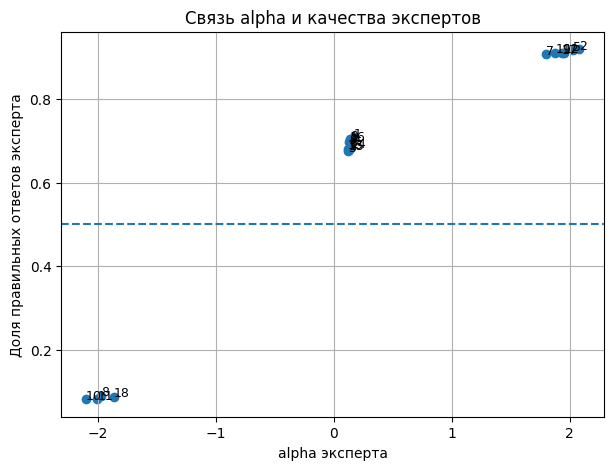

In [7]:
plt.figure(figsize=(7, 5))
plt.scatter(alpha, expert_accuracy)
for j, (a, acc) in enumerate(zip(alpha, expert_accuracy)):
    plt.text(a, acc, str(j), fontsize=9)
plt.axhline(0.5, linestyle='--')
plt.xlabel('alpha эксперта')
plt.ylabel('Доля правильных ответов эксперта')
plt.title('Связь alpha и качества экспертов')
plt.grid(True)
plt.show()


**Комментарий.** Положительный `alpha` означает, что эксперт чаще совпадает с истинной меткой. Отрицательный `alpha` означает систематически инвертированное поведение: такой эксперт чаще выбирает неправильный класс, чем правильный. Чем больше `|alpha|`, тем сильнее модель доверяет закономерности в ответах эксперта: положительной или отрицательной.


## 6. GLAD с контрольными заданиями с известными ответами


In [8]:
def em_with_known_labels(L, y, known_count=20, n_steps=500, lr=1e-2):
    known_labels = np.full(len(y), np.nan)
    idx0 = np.where(y == 0)[0][:known_count // 2]
    idx1 = np.where(y == 1)[0][:known_count - len(idx0)]
    known_idx = np.r_[idx0, idx1]
    known_labels[known_idx] = y[known_idx]
    return em(L, n_steps=n_steps, lr=lr, known_labels=known_labels, random_state=seed, verbose=False), known_idx

(alpha_known, beta_known, q_known, hist_known), known_idx = em_with_known_labels(L, y, known_count=20)
pred_known = (q_known[1] > q_known[0]).astype(int)
acc_known, flip_known = best_binary_accuracy(pred_known, y)
if flip_known:
    pred_known = 1 - pred_known
    alpha_known = -alpha_known

print(f'Использовано контрольных заданий: {len(known_idx)}')
print(f'Accuracy GLAD без контрольных заданий: {em_acc:.4f}')
print(f'Accuracy GLAD с контрольными заданиями: {acc_known:.4f}')
print('\nОтрицательные alpha после добавления контрольных заданий:', np.where(alpha_known < 0)[0].tolist())


Использовано контрольных заданий: 20
Accuracy GLAD без контрольных заданий: 0.9535
Accuracy GLAD с контрольными заданиями: 0.9545

Отрицательные alpha после добавления контрольных заданий: [8, 10, 11, 18]


## 7. Подготовка модулей для word alignment


In [9]:
%%writefile preprocessing.py
from dataclasses import dataclass
from typing import Dict, List, Tuple
from collections import Counter
import re
import xml.etree.ElementTree as ET

import numpy as np

_XML_DECL_RE = re.compile(r'^\s*<\?xml[^>]*\?>', re.IGNORECASE)
_BARE_AMP_RE = re.compile(r'&(?!#\d+;|#x[0-9A-Fa-f]+;|[A-Za-z][A-Za-z0-9]+;)')


@dataclass(frozen=True)
class SentencePair:
    """Contains lists of tokens for source and target sentence."""
    source: List[str]
    target: List[str]


@dataclass(frozen=True)
class TokenizedSentencePair:
    """Contains arrays of token vocabulary indices."""
    source_tokens: np.ndarray
    target_tokens: np.ndarray


@dataclass(frozen=True)
class LabeledAlignment:
    """Positions are numbered from 1. First coordinate is source position."""
    sure: List[Tuple[int, int]]
    possible: List[Tuple[int, int]]


def _text_of_first(elem, names):
    names = {name.lower() for name in names}
    for child in list(elem):
        tag = child.tag.split('}')[-1].lower()
        if tag in names:
            return (child.text or '').strip()
    return ''


def _parse_alignment(text: str) -> List[Tuple[int, int]]:
    pairs = []
    if not text:
        return pairs
    for a, b in re.findall(r'(\d+)\s*[-:,]\s*(\d+)', text):
        pairs.append((int(a), int(b)))
    if not pairs:
        nums = [int(x) for x in re.findall(r'\d+', text)]
        pairs = list(zip(nums[::2], nums[1::2]))
    return pairs


def _prepare_xml(content: str, wrap: bool = False) -> str:
    """Make CzEnAli XML-like files parseable by ElementTree."""
    content = _BARE_AMP_RE.sub('&amp;', content)
    if wrap:
        content = _XML_DECL_RE.sub('', content, count=1).lstrip()
        return '<root>\n' + content + '\n</root>'
    return content


def extract_sentences(filename: str) -> Tuple[List[SentencePair], List[LabeledAlignment]]:
    """Parse CzEnAli-style XML/WA file."""
    with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()

    try:
        root = ET.fromstring(_prepare_xml(content))
    except ET.ParseError:
        root = ET.fromstring(_prepare_xml(content, wrap=True))

    sentence_pairs = []
    alignments = []
    nodes = [root] if root.tag.split('}')[-1].lower() in {'s', 'sentence'} else list(root.iter())

    for node in nodes:
        tag = node.tag.split('}')[-1].lower()
        if tag not in {'s', 'sentence'}:
            continue

        src = _text_of_first(node, ['english', 'source', 'src', 'en'])
        tgt = _text_of_first(node, ['czech', 'target', 'tgt', 'cz', 'cs'])
        sure = _text_of_first(node, ['sure', 'certain'])
        possible = _text_of_first(node, ['possible', 'probable'])

        if not src or not tgt:
            continue

        src_tokens = src.split()
        tgt_tokens = tgt.split()
        sure_pairs = _parse_alignment(sure)
        possible_pairs = _parse_alignment(possible)
        possible_set = set(possible_pairs) | set(sure_pairs)

        sentence_pairs.append(SentencePair(src_tokens, tgt_tokens))
        alignments.append(LabeledAlignment(sorted(set(sure_pairs)), sorted(possible_set)))

    return sentence_pairs, alignments


def get_token_to_index(sentence_pairs: List[SentencePair], freq_cutoff=None) -> Tuple[Dict[str, int], Dict[str, int]]:
    """Create source and target token->index dictionaries."""
    src_counter = Counter()
    tgt_counter = Counter()
    for sent in sentence_pairs:
        src_counter.update(sent.source)
        tgt_counter.update(sent.target)

    def build(counter):
        items = counter.most_common(freq_cutoff) if freq_cutoff is not None else sorted(counter.items())
        tokens = [token for token, _ in items]
        return {token: i for i, token in enumerate(tokens)}

    return build(src_counter), build(tgt_counter)


def tokenize_sents(sentence_pairs: List[SentencePair], source_dict, target_dict) -> List[TokenizedSentencePair]:
    """Transform token strings to vocabulary indices; skip empty-after-filtering pairs."""
    result = []
    for sent in sentence_pairs:
        src = np.array([source_dict[t] for t in sent.source if t in source_dict], dtype=np.int32)
        tgt = np.array([target_dict[t] for t in sent.target if t in target_dict], dtype=np.int32)
        if len(src) > 0 and len(tgt) > 0:
            result.append(TokenizedSentencePair(src, tgt))
    return result


Overwriting preprocessing.py


In [10]:
%%writefile quality.py
from typing import List, Tuple
from preprocessing import LabeledAlignment


def compute_precision(reference: List[LabeledAlignment], predicted: List[List[Tuple[int, int]]]) -> Tuple[int, int]:
    intersection = 0
    total_predicted = 0
    for ref, pred in zip(reference, predicted):
        pred_set = set(pred)
        possible_set = set(ref.possible) | set(ref.sure)
        intersection += len(pred_set & possible_set)
        total_predicted += len(pred_set)
    return intersection, total_predicted


def compute_recall(reference: List[LabeledAlignment], predicted: List[List[Tuple[int, int]]]) -> Tuple[int, int]:
    intersection = 0
    total_sure = 0
    for ref, pred in zip(reference, predicted):
        pred_set = set(pred)
        sure_set = set(ref.sure)
        intersection += len(pred_set & sure_set)
        total_sure += len(sure_set)
    return intersection, total_sure


def compute_aer(reference: List[LabeledAlignment], predicted: List[List[Tuple[int, int]]]) -> float:
    prec_num, total_pred = compute_precision(reference, predicted)
    rec_num, total_sure = compute_recall(reference, predicted)
    denom = total_pred + total_sure
    if denom == 0:
        return 0.0
    return 1.0 - (prec_num + rec_num) / denom


Overwriting quality.py


In [11]:
%%writefile models.py
from abc import ABC, abstractmethod
from itertools import product
from typing import Dict, List, Tuple

import numpy as np

from preprocessing import TokenizedSentencePair


class BaseAligner(ABC):
    @abstractmethod
    def fit(self, parallel_corpus: List[TokenizedSentencePair]):
        pass

    @abstractmethod
    def align(self, sentences: List[TokenizedSentencePair]) -> List[List[Tuple[int, int]]]:
        pass


class DiceAligner(BaseAligner):
    def __init__(self, num_source_words: int, num_target_words: int, threshold=0.5):
        self.cooc = np.zeros((num_source_words, num_target_words), dtype=np.uint32)
        self.dice_scores = None
        self.threshold = threshold

    def fit(self, parallel_corpus):
        for sentence in parallel_corpus:
            for source_token in np.unique(sentence.source_tokens):
                for target_token in np.unique(sentence.target_tokens):
                    self.cooc[source_token, target_token] += 1
        denom = self.cooc.sum(0, keepdims=True) + self.cooc.sum(1, keepdims=True)
        self.dice_scores = np.divide(2 * self.cooc.astype(np.float32), denom,
                                     out=np.zeros_like(self.cooc, dtype=np.float32), where=denom != 0)
        return []

    def align(self, sentences):
        result = []
        for sentence in sentences:
            alignment = []
            for (i, source_token), (j, target_token) in product(enumerate(sentence.source_tokens, 1), enumerate(sentence.target_tokens, 1)):
                if self.dice_scores[source_token, target_token] > self.threshold:
                    alignment.append((i, j))
            result.append(alignment)
        return result


class WordAligner(BaseAligner):
    def __init__(self, num_source_words, num_target_words, num_iters):
        self.num_source_words = num_source_words
        self.num_target_words = num_target_words
        self.translation_probs = np.full((num_source_words, num_target_words), 1 / num_target_words, dtype=np.float32)
        self.num_iters = num_iters

    def _e_step(self, parallel_corpus: List[TokenizedSentencePair]) -> List[np.array]:
        posteriors = []
        for sent in parallel_corpus:
            scores = self.translation_probs[np.ix_(sent.source_tokens, sent.target_tokens)].astype(np.float64)
            denom = scores.sum(axis=0, keepdims=True)
            posterior = np.divide(scores, denom, out=np.full_like(scores, 1 / len(sent.source_tokens)), where=denom > 0)
            posteriors.append(posterior.astype(np.float32))
        return posteriors

    def _compute_elbo(self, parallel_corpus: List[TokenizedSentencePair], posteriors: List[np.array]) -> float:
        elbo = 0.0
        eps = 1e-12
        for sent, posterior in zip(parallel_corpus, posteriors):
            theta = self.translation_probs[np.ix_(sent.source_tokens, sent.target_tokens)]
            log_prior = -np.log(len(sent.source_tokens))
            elbo += np.sum(posterior * (np.log(theta + eps) + log_prior - np.log(posterior + eps)))
        return float(elbo)

    def _m_step(self, parallel_corpus: List[TokenizedSentencePair], posteriors: List[np.array]):
        counts = np.zeros_like(self.translation_probs, dtype=np.float32)
        for sent, posterior in zip(parallel_corpus, posteriors):
            for src_pos, src_token in enumerate(sent.source_tokens):
                np.add.at(counts[src_token], sent.target_tokens, posterior[src_pos])

        row_sums = counts.sum(axis=1, keepdims=True)
        self.translation_probs = np.divide(counts, row_sums,
                                           out=np.full_like(counts, 1 / self.num_target_words, dtype=np.float32),
                                           where=row_sums > 0)
        return self._compute_elbo(parallel_corpus, posteriors)

    def fit(self, parallel_corpus):
        history = []
        for _ in range(self.num_iters):
            posteriors = self._e_step(parallel_corpus)
            history.append(self._m_step(parallel_corpus, posteriors))
        return history

    def align(self, sentences):
        result = []
        for sent in sentences:
            scores = self.translation_probs[np.ix_(sent.source_tokens, sent.target_tokens)]
            best_src_pos = scores.argmax(axis=0)
            result.append([(int(src_pos + 1), int(tgt_pos + 1)) for tgt_pos, src_pos in enumerate(best_src_pos)])
        return result


class WordPositionAligner(WordAligner):
    def __init__(self, num_source_words, num_target_words, num_iters):
        super().__init__(num_source_words, num_target_words, num_iters)
        self.alignment_probs: Dict[Tuple[int, int], np.ndarray] = {}

    def _get_probs_for_lengths(self, src_length: int, tgt_length: int):
        key = (src_length, tgt_length)
        if key not in self.alignment_probs:
            self.alignment_probs[key] = np.full((src_length, tgt_length), 1 / src_length, dtype=np.float32)
        return self.alignment_probs[key]

    def _e_step(self, parallel_corpus):
        posteriors = []
        for sent in parallel_corpus:
            theta = self.translation_probs[np.ix_(sent.source_tokens, sent.target_tokens)].astype(np.float64)
            phi = self._get_probs_for_lengths(len(sent.source_tokens), len(sent.target_tokens)).astype(np.float64)
            scores = theta * phi
            denom = scores.sum(axis=0, keepdims=True)
            posterior = np.divide(scores, denom, out=np.full_like(scores, 1 / len(sent.source_tokens)), where=denom > 0)
            posteriors.append(posterior.astype(np.float32))
        return posteriors

    def _compute_elbo(self, parallel_corpus, posteriors):
        elbo = 0.0
        eps = 1e-12
        for sent, posterior in zip(parallel_corpus, posteriors):
            theta = self.translation_probs[np.ix_(sent.source_tokens, sent.target_tokens)]
            phi = self._get_probs_for_lengths(len(sent.source_tokens), len(sent.target_tokens))
            elbo += np.sum(posterior * (np.log(theta + eps) + np.log(phi + eps) - np.log(posterior + eps)))
        return float(elbo)

    def _m_step(self, parallel_corpus, posteriors):
        counts = np.zeros_like(self.translation_probs, dtype=np.float32)
        alignment_counts = {}

        for sent, posterior in zip(parallel_corpus, posteriors):
            for src_pos, src_token in enumerate(sent.source_tokens):
                np.add.at(counts[src_token], sent.target_tokens, posterior[src_pos])

            key = (len(sent.source_tokens), len(sent.target_tokens))
            if key not in alignment_counts:
                alignment_counts[key] = np.zeros((key[0], key[1]), dtype=np.float32)
            alignment_counts[key] += posterior

        row_sums = counts.sum(axis=1, keepdims=True)
        self.translation_probs = np.divide(counts, row_sums,
                                           out=np.full_like(counts, 1 / self.num_target_words, dtype=np.float32),
                                           where=row_sums > 0)

        for key, mat in alignment_counts.items():
            col_sums = mat.sum(axis=0, keepdims=True)
            self.alignment_probs[key] = np.divide(mat, col_sums,
                                                  out=np.full_like(mat, 1 / key[0], dtype=np.float32),
                                                  where=col_sums > 0)

        return self._compute_elbo(parallel_corpus, posteriors)

    def align(self, sentences):
        result = []
        for sent in sentences:
            theta = self.translation_probs[np.ix_(sent.source_tokens, sent.target_tokens)]
            phi = self._get_probs_for_lengths(len(sent.source_tokens), len(sent.target_tokens))
            scores = theta * phi
            best_src_pos = scores.argmax(axis=0)
            result.append([(int(src_pos + 1), int(tgt_pos + 1)) for tgt_pos, src_pos in enumerate(best_src_pos)])
        return result


Overwriting models.py


## 8. Скачивание и распаковка корпуса, если его нет


In [12]:
def ensure_czenali_dataset():
    data_dir = Path('data/merged_data')
    if data_dir.exists() and list(data_dir.rglob('*.wa')):
        print('Корпус уже найден:', data_dir)
        return data_dir

    archive = Path('CzEnAli_1.0.tar.gz')
    url = 'https://lindat.mff.cuni.cz/repository/xmlui/bitstream/handle/11234/1-1804/CzEnAli_1.0.tar.gz'

    if not archive.exists():
        print('Корпус не найден. Скачиваю архив...')
        urllib.request.urlretrieve(url, archive)
    else:
        print('Архив уже найден:', archive)

    Path('data').mkdir(exist_ok=True)
    print('Распаковываю архив...')
    with tarfile.open(archive, 'r:gz') as tar:
        tar.extractall('data')

    if not data_dir.exists():
        candidates = list(Path('data').rglob('*.wa'))
        if not candidates:
            raise FileNotFoundError('После распаковки не удалось найти .wa-файлы корпуса.')
        print('Найдены .wa-файлы, но путь отличается от ожидаемого.')
    else:
        print('Корпус готов:', data_dir)
    return data_dir

data_dir = ensure_czenali_dataset()
wa_files = sorted(data_dir.rglob('*.wa'))
print('Количество .wa-файлов:', len(wa_files))
print('Первый файл:', wa_files[0] if wa_files else 'нет файлов')


Корпус уже найден: data\merged_data
Количество .wa-файлов: 62
Первый файл: data\merged_data\celex\celex_21990A0714.wa


## 9. Парсинг корпуса и токенизация


In [13]:
from preprocessing import extract_sentences, get_token_to_index, tokenize_sents

all_sentences = []
all_targets = []

for filename in wa_files:
    sent_pairs, aligns = extract_sentences(str(filename))
    all_sentences.extend(sent_pairs)
    all_targets.extend(aligns)

print('Количество размеченных пар предложений:', len(all_sentences))
print('Пример sentence pair:', all_sentences[0] if all_sentences else None)
print('Пример alignment:', all_targets[0] if all_targets else None)


Количество размеченных пар предложений: 2501
Пример sentence pair: SentencePair(source=['Relationship', 'of', 'ICOs', 'and', 'ICBs', 'with', 'the', 'Fund'], target=['Vztah', 'mezinárodních', 'organizací', 'pro', 'suroviny', 'a', 'mezinárodních', 'subjektů', 'pro', 'suroviny', 'k', 'fondu'])
Пример alignment: LabeledAlignment(sure=[(1, 1), (3, 2), (3, 3), (3, 4), (3, 5), (4, 6), (5, 7), (5, 8), (5, 9), (5, 10), (6, 11), (8, 12)], possible=[(1, 1), (2, 3), (3, 2), (3, 3), (3, 4), (3, 5), (4, 6), (5, 7), (5, 8), (5, 9), (5, 10), (6, 11), (7, 12), (8, 12)])


In [14]:
t_idx_src, t_idx_tgt = get_token_to_index(all_sentences)
tokenized_sentences = tokenize_sents(all_sentences, t_idx_src, t_idx_tgt)

print('Размер source vocabulary:', len(t_idx_src))
print('Размер target vocabulary:', len(t_idx_tgt))
print('Количество токенизированных предложений:', len(tokenized_sentences))


Размер source vocabulary: 9048
Размер target vocabulary: 15002
Количество токенизированных предложений: 2501


## 10. Baseline: DiceAligner и метрики


In [15]:
from models import DiceAligner
from quality import compute_precision, compute_recall, compute_aer

baseline = DiceAligner(len(t_idx_src), len(t_idx_tgt), threshold=0.01)
baseline.fit(tokenized_sentences)
baseline_pred = baseline.align(tokenized_sentences)

p_num, p_den = compute_precision(all_targets, baseline_pred)
r_num, r_den = compute_recall(all_targets, baseline_pred)
print(f'Dice precision: {p_num / p_den:.4f}' if p_den else 'Dice precision: нет предсказаний')
print(f'Dice recall:    {r_num / r_den:.4f}' if r_den else 'Dice recall: нет sure-разметки')
print(f'Dice AER:       {compute_aer(all_targets, baseline_pred):.4f}')


Dice precision: 0.1164
Dice recall:    0.6934
Dice AER:       0.8074


## 11. Формулы EM для базовой модели WordAligner

Для предложения `S=(s_1,...,s_n)` и перевода `T=(t_1,...,t_m)`:

$$p(A,T|S)=\prod_{i=1}^{m}\frac{1}{n}\theta(t_i|s_{a_i}).$$

**E-шаг:**

$$q_i(j)=p(a_i=j|S,T)=\frac{\theta(t_i|s_j)}{\sum_{k=1}^{n}\theta(t_i|s_k)}.$$

**M-шаг:**

$$\theta(y|x)=\frac{\sum_{(S,T)}\sum_i\sum_j q_i(j)[s_j=x][t_i=y]}{\sum_{(S,T)}\sum_i\sum_j q_i(j)[s_j=x]}.$$

**ELBO:**

$$\mathcal{L}=\sum_{(S,T)}\sum_i\sum_j q_i(j)\left(\log\theta(t_i|s_j)-\log n-\log q_i(j)\right).$$


## 12. WordAligner: обучение и качество


In [16]:
from models import WordAligner

word_aligner = WordAligner(len(t_idx_src), len(t_idx_tgt), num_iters=20)
word_history = word_aligner.fit(tokenized_sentences)
word_pred = word_aligner.align(tokenized_sentences)

print(f'WordAligner AER: {compute_aer(all_targets, word_pred):.4f}')
print('Первые значения ELBO:', [round(x, 2) for x in word_history[:5]])
print('Последние значения ELBO:', [round(x, 2) for x in word_history[-5:]])


WordAligner AER: 0.5747
Первые значения ELBO: [-302090.86, -230012.68, -217269.51, -211131.05, -207887.44]
Последние значения ELBO: [-202750.59, -202705.73, -202669.46, -202639.77, -202615.2]


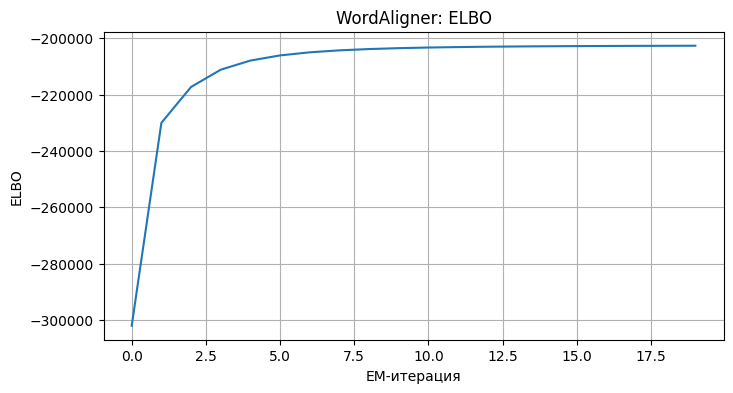

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(word_history)
plt.xlabel('EM-итерация')
plt.ylabel('ELBO')
plt.title('WordAligner: ELBO')
plt.grid(True)
plt.show()


## 13. Получение переводов в обратном направлении target → source


In [18]:
idx_token_src = {index: token for token, index in t_idx_src.items()}
idx_token_tgt = {index: token for token, index in t_idx_tgt.items()}

source_counts = np.ones(len(t_idx_src), dtype=np.float64)
for sent in tokenized_sentences:
    np.add.at(source_counts, sent.source_tokens, 1)
source_prior = source_counts / source_counts.sum()

reverse_probs = word_aligner.translation_probs.astype(np.float64) * source_prior[:, None]
reverse_probs /= reverse_probs.sum(axis=0, keepdims=True) + 1e-12


def top_target_translations(source_word, k=5):
    if source_word not in t_idx_src:
        return []
    row = word_aligner.translation_probs[t_idx_src[source_word]]
    return [(idx_token_tgt[i], float(row[i])) for i in row.argsort()[-k:][::-1]]


def top_source_translations(target_word, k=5):
    if target_word not in t_idx_tgt:
        return []
    col = reverse_probs[:, t_idx_tgt[target_word]]
    return [(idx_token_src[i], float(col[i])) for i in col.argsort()[-k:][::-1]]

for word in ['Mr', 'Mrs', 'water', 'on']:
    print(f'{word} ->', top_target_translations(word, 3))

print('\nОбратное направление:')
for word in list(t_idx_tgt.keys())[:5]:
    print(f'{word} ->', top_source_translations(word, 3))


Mr -> [('pan', 0.5247328877449036), ('řekl', 0.28382235765457153), ('Pan', 0.13361689448356628)]
Mrs -> [('paní', 0.9899491667747498), ('Mannová', 0.008749647065997124), ('-', 0.0006627418333664536)]
water -> [('vody', 0.4240804612636566), ('pro', 0.20398667454719543), ('z', 0.20348967611789703)]
on -> [('na', 0.917359471321106), ('se', 0.03901036083698273), ('.', 0.03312484174966812)]

Обратное направление:
! -> [('!', 0.9031186464589693), ('sir', 0.053398903302675466), ('Live', 0.004328723497430776)]
" -> [('"', 0.6056691577022869), ('``', 0.14488418878090156), ("''", 0.13745475790849412)]
$ -> [('yield', 0.23623354874516572), ('10.72', 0.09781690380265791), ('Copenhagen', 0.06589901551612136)]
% -> [('%', 0.992503095559126), ('private-sector', 0.001053363872295514), ('electrical', 0.001053363872295514)]
& -> [('&', 0.998822891254042), ('Broad', 0.000430493547420074), ('Kaufman', 0.000430493547420074)]


## 14. Визуализация выравниваний


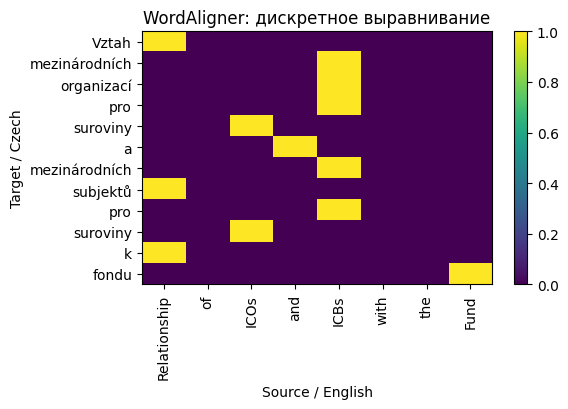

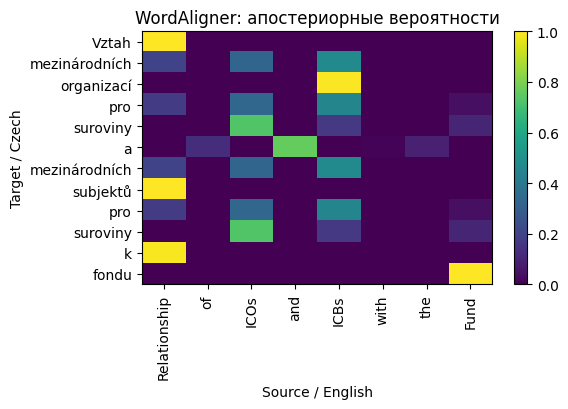

In [19]:
def alignment_matrix(pred_alignment, src_len, tgt_len):
    mat = np.zeros((tgt_len, src_len), dtype=float)
    for src_pos, tgt_pos in pred_alignment:
        if 1 <= src_pos <= src_len and 1 <= tgt_pos <= tgt_len:
            mat[tgt_pos - 1, src_pos - 1] = 1.0
    return mat


def plot_alignment(sentence_pair, matrix, title):
    plt.figure(figsize=(max(6, len(sentence_pair.source) * 0.6), max(4, len(sentence_pair.target) * 0.35)))
    plt.imshow(matrix, aspect='auto')
    plt.xticks(range(len(sentence_pair.source)), sentence_pair.source, rotation=90)
    plt.yticks(range(len(sentence_pair.target)), sentence_pair.target)
    plt.xlabel('Source / English')
    plt.ylabel('Target / Czech')
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

example_id = 0
sent_raw = all_sentences[example_id]
sent_tok = tokenized_sentences[example_id]
pred = word_aligner.align([sent_tok])[0]
discrete_mat = alignment_matrix(pred, len(sent_tok.source_tokens), len(sent_tok.target_tokens))
plot_alignment(sent_raw, discrete_mat, 'WordAligner: дискретное выравнивание')

posterior_mat = word_aligner._e_step([sent_tok])[0].T
plot_alignment(sent_raw, posterior_mat, 'WordAligner: апостериорные вероятности')


## 15. Формулы EM для WordPositionAligner

Теперь априорная вероятность позиции не равномерная, а зависит от длин предложений:

$$p(A,T|S)=\prod_{i=1}^{m}\phi_{m,n}(a_i|i)\theta(t_i|s_{a_i}).$$

**E-шаг:**

$$q_i(j)=\frac{\phi_{m,n}(j|i)\theta(t_i|s_j)}{\sum_{k=1}^{n}\phi_{m,n}(k|i)\theta(t_i|s_k)}.$$

**M-шаг для переводов:** такой же, как в базовой модели, но с новыми `q`.

**M-шаг для позиций:**

$$\phi_{m,n}(j|i)=\frac{\sum_{(S,T): |S|=n, |T|=m} q_i(j)}{\sum_{(S,T): |S|=n, |T|=m}\sum_{k=1}^{n} q_i(k)}.$$

**ELBO:**

$$\mathcal{L}=\sum_{(S,T)}\sum_i\sum_j q_i(j)\left(\log\theta(t_i|s_j)+\log\phi_{m,n}(j|i)-\log q_i(j)\right).$$


## 16. WordPositionAligner: обучение и сравнение


In [20]:
from models import WordPositionAligner

position_aligner = WordPositionAligner(len(t_idx_src), len(t_idx_tgt), num_iters=20)
pos_history = position_aligner.fit(tokenized_sentences)
pos_pred = position_aligner.align(tokenized_sentences)

print(f'Dice AER:                {compute_aer(all_targets, baseline_pred):.4f}')
print(f'WordAligner AER:         {compute_aer(all_targets, word_pred):.4f}')
print(f'WordPositionAligner AER: {compute_aer(all_targets, pos_pred):.4f}')


Dice AER:                0.8074
WordAligner AER:         0.5747
WordPositionAligner AER: 0.5910


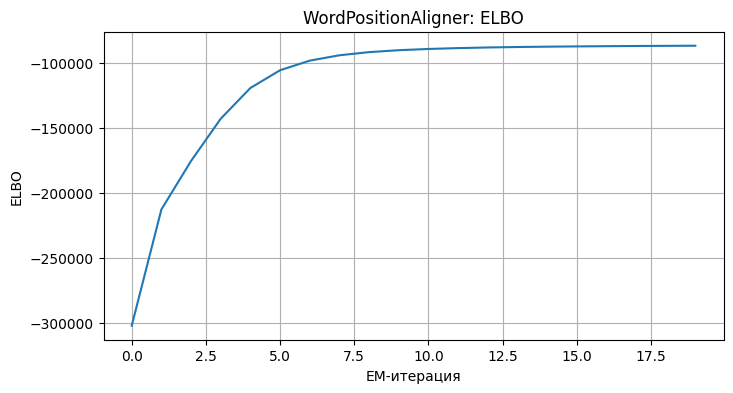

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(pos_history)
plt.xlabel('EM-итерация')
plt.ylabel('ELBO')
plt.title('WordPositionAligner: ELBO')
plt.grid(True)
plt.show()


## 17. Инициализация WordPositionAligner параметрами WordAligner


In [22]:
word_10 = WordAligner(len(t_idx_src), len(t_idx_tgt), num_iters=10)
word_10_history = word_10.fit(tokenized_sentences)

position_from_word = WordPositionAligner(len(t_idx_src), len(t_idx_tgt), num_iters=10)
position_from_word.translation_probs = word_10.translation_probs.copy()
pos_from_word_history = position_from_word.fit(tokenized_sentences)
pos_from_word_pred = position_from_word.align(tokenized_sentences)

print(f'WordPositionAligner с нуля, 20 эпох AER:       {compute_aer(all_targets, pos_pred):.4f}')
print(f'WordAligner 10 + PositionAligner 10 эпох AER: {compute_aer(all_targets, pos_from_word_pred):.4f}')


WordPositionAligner с нуля, 20 эпох AER:       0.5910
WordAligner 10 + PositionAligner 10 эпох AER: 0.5561


## 18. Простое улучшение качества: пересечение направлений


In [23]:
from preprocessing import SentencePair, TokenizedSentencePair

reversed_sentences_raw = [SentencePair(s.target, s.source) for s in all_sentences]
rev_src_dict, rev_tgt_dict = get_token_to_index(reversed_sentences_raw)
rev_tokenized = tokenize_sents(reversed_sentences_raw, rev_src_dict, rev_tgt_dict)

rev_aligner = WordAligner(len(rev_src_dict), len(rev_tgt_dict), num_iters=20)
rev_aligner.fit(rev_tokenized)
rev_pred = rev_aligner.align(rev_tokenized)

rev_pred_flipped = [[(eng_pos, cze_pos) for cze_pos, eng_pos in sent] for sent in rev_pred]
intersection_pred = [sorted(set(a) & set(b)) for a, b in zip(word_pred, rev_pred_flipped)]

print(f'WordAligner direct AER:        {compute_aer(all_targets, word_pred):.4f}')
print(f'Reverse intersection AER:      {compute_aer(all_targets, intersection_pred):.4f}')

p_num, p_den = compute_precision(all_targets, intersection_pred)
r_num, r_den = compute_recall(all_targets, intersection_pred)
print(f'Intersection precision: {p_num / p_den:.4f}' if p_den else 'Intersection precision: нет предсказаний')
print(f'Intersection recall:    {r_num / r_den:.4f}' if r_den else 'Intersection recall: нет sure-разметки')


WordAligner direct AER:        0.5747
Reverse intersection AER:      0.5009
Intersection precision: 0.8132
Intersection recall:    0.3570


## 19. Итоговая сводка


In [24]:
summary = {
    'Majority voting accuracy': majority_acc,
    'GLAD EM accuracy': em_acc,
    'GLAD with known labels accuracy': acc_known,
    'Dice AER': compute_aer(all_targets, baseline_pred),
    'WordAligner AER': compute_aer(all_targets, word_pred),
    'WordPositionAligner AER': compute_aer(all_targets, pos_pred),
    'Intersection AER': compute_aer(all_targets, intersection_pred),
}

for name, value in summary.items():
    print(f'{name:36s}: {value:.4f}')


Majority voting accuracy            : 0.8920
GLAD EM accuracy                    : 0.9535
GLAD with known labels accuracy     : 0.9545
Dice AER                            : 0.8074
WordAligner AER                     : 0.5747
WordPositionAligner AER             : 0.5910
Intersection AER                    : 0.5009
